# 05 _ Prophet Forecasting Comparison

**Project:** Corporacion Favorita Store Sales Forecasting  
**Project type:** Data Science / MLOps Portfolio Project  
**Notebook:** `notebooks/05_prophet_comparison.ipynb`

---

## 1.Purpose

This notebook evaluates Prophet as a complementary and interpretable forecasting approach.

The goal is not to replace LightGBM, but to compare a classical time series model against the main machine learning model at an aggregate business level.


# 2.Notebook Objective

The objective of this notebook is to train Prophet on daily total sales and compare it against aggregated LightGBM predictions over the same validation horizon.

The notebook will:

- Prepare a daily aggregate sales series.
- Train Prophet on historical total daily sales.
- Validate Prophet on the 16-day validation horizon.
- Compare Prophet with LightGBM at daily aggregate level.
- Analyze Prophet components.
- Document business implications.
- Save Prophet artifacts for final model comparison.


# 3.Scope.

## Scope.

This notebook uses Prophet as an interpretable aggregate benchmark.

It includes:

- Daily total sales preparation.
- Prophet training and validation.
- Aggregate comparison with LightGBM.
- Component interpretation.
- Saved Prophet metrics, predictions, figures, and model artifacts.

It does not include:

- Store-family-level Prophet modeling.
- Kaggle submission generation.
- Replacement of the main LightGBM model.
- MLflow tracking.
- API or Docker development.


# 4.Imports and Path Setup

This section imports the required libraries, detects the project root, defines input/output paths, validates prior artifacts, and checks that Prophet is available.


In [1]:
from pathlib import Path
from datetime import datetime
import json
import os
import platform
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

try:
    import prophet
    from prophet import Prophet
    from prophet.serialize import model_to_json, model_from_json
except ImportError as error:
    raise ImportError(
        "Prophet is required for this notebook. "
        "Install it with: %pip install prophet and restart the kernel."
    ) from error


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

SEED = 42
np.random.seed(SEED)

MODEL_VERSION = "prophet_total_sales_v1"
VALIDATION_START_DATE = pd.Timestamp("2017-07-31")
VALIDATION_END_DATE = pd.Timestamp("2017-08-15")


def find_project_root(
    start_path=None, required_dirs=("data", "notebooks", "reports", "models")
):
    """
    Find the project root by walking upward from the current working directory.

    The project root is identified as the nearest parent directory containing
    the required project folders.
    """
    current_path = Path.cwd() if start_path is None else Path(start_path)
    current_path = current_path.resolve()

    candidate_paths = [current_path] + list(current_path.parents)

    for candidate_path in candidate_paths:
        if all((candidate_path / directory).exists() for directory in required_dirs):
            return candidate_path

    raise FileNotFoundError(
        "Project root could not be detected. "
        f"Expected a parent directory containing: {required_dirs}. "
        f"Current working directory: {current_path}"
    )


def format_file_size_mb(path):
    """Return file size in MB if the file exists."""
    path = Path(path)

    if not path.exists():
        return np.nan

    return round(path.stat().st_size / (1024**2), 2)


def dataframe_memory_mb(df):
    """Return DataFrame memory usage in MB."""
    return round(df.memory_usage(deep=True).sum() / (1024**2), 2)


def save_json(data, path):
    """Save a dictionary as a formatted JSON file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4, ensure_ascii=False, default=str)


def save_dataframe_csv(df, path):
    """Save a DataFrame as CSV."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_dataframe_parquet(df, path):
    """Save a DataFrame as parquet."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
FEATURES_DIR = DATA_DIR / "features"
PREDICTIONS_DIR = DATA_DIR / "predictions"

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_TABLES_DIR = REPORTS_DIR / "tables"
REPORTS_FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR = PROJECT_ROOT / "models"
PROPHET_MODELS_DIR = MODELS_DIR / "prophet"

PROPHET_MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_TRAIN_FEATURES_PATH = FEATURES_DIR / "baseline_train_features.parquet"
BASELINE_VALID_FEATURES_PATH = FEATURES_DIR / "baseline_valid_features.parquet"

LIGHTGBM_VALIDATION_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / "lightgbm_v1_validation_predictions.parquet"
)

LIGHTGBM_METRICS_PATH = REPORTS_TABLES_DIR / "lightgbm_v1_metrics.csv"

LIGHTGBM_BASELINE_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / "lightgbm_v1_baseline_comparison.csv"
)

HOLIDAYS_EVENTS_PATH = RAW_DIR / "holidays_events.csv"

PROPHET_MODEL_PATH = PROPHET_MODELS_DIR / f"{MODEL_VERSION}_model.json"
PROPHET_CONFIG_PATH = PROPHET_MODELS_DIR / f"{MODEL_VERSION}_config.json"

PROPHET_EXPERIMENT_SUMMARY_PATH = (
    PROPHET_MODELS_DIR / f"{MODEL_VERSION}_experiment_summary.json"
)

PROPHET_VALIDATION_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / f"{MODEL_VERSION}_validation_predictions.parquet"
)

PROPHET_METRICS_PATH = REPORTS_TABLES_DIR / f"{MODEL_VERSION}_metrics.csv"

PROPHET_DAILY_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_vs_lightgbm_daily_comparison.csv"
)

PROPHET_FORECAST_FIGURE_PATH = REPORTS_FIGURES_DIR / f"{MODEL_VERSION}_forecast.png"

PROPHET_COMPONENTS_FIGURE_PATH = REPORTS_FIGURES_DIR / f"{MODEL_VERSION}_components.png"

required_input_files = {
    "BASELINE_TRAIN_FEATURES_PATH": BASELINE_TRAIN_FEATURES_PATH,
    "BASELINE_VALID_FEATURES_PATH": BASELINE_VALID_FEATURES_PATH,
    "LIGHTGBM_VALIDATION_PREDICTIONS_PATH": LIGHTGBM_VALIDATION_PREDICTIONS_PATH,
    "LIGHTGBM_METRICS_PATH": LIGHTGBM_METRICS_PATH,
    "LIGHTGBM_BASELINE_COMPARISON_PATH": LIGHTGBM_BASELINE_COMPARISON_PATH,
}

optional_input_files = {
    "HOLIDAYS_EVENTS_PATH": HOLIDAYS_EVENTS_PATH,
}

input_file_inventory = pd.DataFrame(
    [
        {
            "file_key": file_key,
            "file_name": path.name,
            "expected_location": str(path.parent.relative_to(PROJECT_ROOT)),
            "required": True,
            "exists": path.exists(),
            "file_size_mb": format_file_size_mb(path),
            "path": path,
        }
        for file_key, path in required_input_files.items()
    ]
    + [
        {
            "file_key": file_key,
            "file_name": path.name,
            "expected_location": str(path.parent.relative_to(PROJECT_ROOT)),
            "required": False,
            "exists": path.exists(),
            "file_size_mb": format_file_size_mb(path),
            "path": path,
        }
        for file_key, path in optional_input_files.items()
    ]
)

display(input_file_inventory)

missing_required_files = input_file_inventory.loc[
    input_file_inventory["required"] & ~input_file_inventory["exists"]
]

if not missing_required_files.empty:
    raise FileNotFoundError(
        "Missing required input files:\n"
        + "\n".join(
            [
                f"- {row.file_key}: {row.path}"
                for row in missing_required_files.itertuples(index=False)
            ]
        )
    )

dependency_versions = pd.DataFrame(
    [
        {"package": "python", "version": platform.python_version()},
        {"package": "pandas", "version": pd.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "prophet", "version": prophet.__version__},
    ]
)

execution_settings = pd.DataFrame(
    [
        {"setting": "model_version", "value": MODEL_VERSION},
        {"setting": "project_root", "value": PROJECT_ROOT},
        {"setting": "validation_start_date", "value": VALIDATION_START_DATE},
        {"setting": "validation_end_date", "value": VALIDATION_END_DATE},
        {"setting": "seed", "value": SEED},
        {"setting": "operating_system", "value": platform.platform()},
        {"setting": "cpu_count", "value": os.cpu_count()},
    ]
)

output_directories = pd.DataFrame(
    [
        {
            "directory": "PROPHET_MODELS_DIR",
            "path": PROPHET_MODELS_DIR,
            "exists": PROPHET_MODELS_DIR.exists(),
        },
        {
            "directory": "PREDICTIONS_DIR",
            "path": PREDICTIONS_DIR,
            "exists": PREDICTIONS_DIR.exists(),
        },
        {
            "directory": "REPORTS_TABLES_DIR",
            "path": REPORTS_TABLES_DIR,
            "exists": REPORTS_TABLES_DIR.exists(),
        },
        {
            "directory": "REPORTS_FIGURES_DIR",
            "path": REPORTS_FIGURES_DIR,
            "exists": REPORTS_FIGURES_DIR.exists(),
        },
    ]
)

display(dependency_versions)
display(execution_settings)
display(output_directories)


.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,file_key,file_name,expected_location,required,exists,file_size_mb,path
0,BASELINE_TRAIN_FEATURES_PATH,baseline_train_features.parquet,data\features,True,True,64.3100,....
1,BASELINE_VALID_FEATURES_PATH,baseline_valid_features.parquet,data\features,True,True,0.8000,....
2,LIGHTGBM_VALIDATION_PREDICTIONS_PATH,lightgbm_v1_validation_predictions.parquet,data\predictions,True,True,1.5800,....
3,LIGHTGBM_METRICS_PATH,lightgbm_v1_metrics.csv,reports\tables,True,True,0.0000,....
4,LIGHTGBM_BASELINE_COMPARISON_PATH,lightgbm_v1_baseline_comparison.csv,reports\tables,True,True,0.0000,....
5,HOLIDAYS_EVENTS_PATH,holidays_events.csv,data\raw,False,True,0.0200,....


,package,version
0,python,3.11.9
1,pandas,3.0.3
2,numpy,2.4.5
3,prophet,1.3.0


,setting,value
0,model_version,prophet_total_sales_v1
1,project_root,.
2,validation_start_date,2017-07-31 00:00:00
3,validation_end_date,2017-08-15 00:00:00
4,seed,42
5,operating_system,Windows-10-10.0.19045-SP0
6,cpu_count,8


,directory,path,exists
0,PROPHET_MODELS_DIR,....,True
1,PREDICTIONS_DIR,....,True
2,REPORTS_TABLES_DIR,....,True
3,REPORTS_FIGURES_DIR,....,True


# 5.Load Required Data and LightGBM Artifacts

This section loads the minimum required data for the Prophet comparison.

Prophet will be trained on daily total sales, so only the `date` and `sales` columns are loaded from the train and validation feature datasets.

The LightGBM validation predictions and metrics are also loaded to allow a fair aggregate-level comparison between Prophet and the main machine learning model.


In [2]:
import gc
import time


def read_parquet_with_log(path, dataset_name, columns=None):
    """Read a parquet file and print a compact loading log."""
    start_time = time.perf_counter()
    print(f"Loading {dataset_name}...")

    df = pd.read_parquet(path, columns=columns)

    elapsed_time = time.perf_counter() - start_time
    memory_mb = dataframe_memory_mb(df)

    print(
        f"Loaded {dataset_name}: "
        f"{df.shape[0]:,} rows, {df.shape[1]:,} columns, "
        f"{memory_mb:,.2f} MB, {elapsed_time:,.2f} seconds"
    )

    return df


train_sales_data = read_parquet_with_log(
    BASELINE_TRAIN_FEATURES_PATH,
    "train_sales_data",
    columns=["date", "sales"],
)

valid_sales_data = read_parquet_with_log(
    BASELINE_VALID_FEATURES_PATH,
    "valid_sales_data",
    columns=["date", "sales"],
)

lightgbm_validation_predictions = read_parquet_with_log(
    LIGHTGBM_VALIDATION_PREDICTIONS_PATH,
    "lightgbm_validation_predictions",
)

lightgbm_metrics = pd.read_csv(LIGHTGBM_METRICS_PATH)
lightgbm_baseline_comparison = pd.read_csv(LIGHTGBM_BASELINE_COMPARISON_PATH)

if HOLIDAYS_EVENTS_PATH.exists():
    holidays_events = pd.read_csv(HOLIDAYS_EVENTS_PATH)
else:
    holidays_events = None

for dataframe in [train_sales_data, valid_sales_data, lightgbm_validation_predictions]:
    if "date" in dataframe.columns:
        dataframe["date"] = pd.to_datetime(dataframe["date"])

if holidays_events is not None and "date" in holidays_events.columns:
    holidays_events["date"] = pd.to_datetime(holidays_events["date"])

required_sales_columns = {"date", "sales"}

missing_train_columns = required_sales_columns - set(train_sales_data.columns)
missing_valid_columns = required_sales_columns - set(valid_sales_data.columns)

if missing_train_columns:
    raise ValueError(
        f"Missing columns in train_sales_data: {sorted(missing_train_columns)}"
    )

if missing_valid_columns:
    raise ValueError(
        f"Missing columns in valid_sales_data: {sorted(missing_valid_columns)}"
    )

required_lightgbm_columns = {"date", "sales", "prediction"}

missing_lightgbm_columns = required_lightgbm_columns - set(
    lightgbm_validation_predictions.columns
)

if missing_lightgbm_columns:
    raise ValueError(
        "Missing columns in lightgbm_validation_predictions: "
        f"{sorted(missing_lightgbm_columns)}"
    )

actual_validation_start = valid_sales_data["date"].min()
actual_validation_end = valid_sales_data["date"].max()

if actual_validation_start != VALIDATION_START_DATE:
    raise ValueError(
        f"Unexpected validation start date. "
        f"Expected {VALIDATION_START_DATE.date()}, found {actual_validation_start.date()}."
    )

if actual_validation_end != VALIDATION_END_DATE:
    raise ValueError(
        f"Unexpected validation end date. "
        f"Expected {VALIDATION_END_DATE.date()}, found {actual_validation_end.date()}."
    )

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": "train_sales_data",
            "rows": len(train_sales_data),
            "columns": train_sales_data.shape[1],
            "memory_mb": dataframe_memory_mb(train_sales_data),
            "start_date": train_sales_data["date"].min(),
            "end_date": train_sales_data["date"].max(),
            "unique_dates": train_sales_data["date"].nunique(),
            "total_sales": train_sales_data["sales"].sum(),
        },
        {
            "dataset": "valid_sales_data",
            "rows": len(valid_sales_data),
            "columns": valid_sales_data.shape[1],
            "memory_mb": dataframe_memory_mb(valid_sales_data),
            "start_date": valid_sales_data["date"].min(),
            "end_date": valid_sales_data["date"].max(),
            "unique_dates": valid_sales_data["date"].nunique(),
            "total_sales": valid_sales_data["sales"].sum(),
        },
        {
            "dataset": "lightgbm_validation_predictions",
            "rows": len(lightgbm_validation_predictions),
            "columns": lightgbm_validation_predictions.shape[1],
            "memory_mb": dataframe_memory_mb(lightgbm_validation_predictions),
            "start_date": lightgbm_validation_predictions["date"].min(),
            "end_date": lightgbm_validation_predictions["date"].max(),
            "unique_dates": lightgbm_validation_predictions["date"].nunique(),
            "total_sales": lightgbm_validation_predictions["sales"].sum(),
        },
    ]
)

artifact_overview = pd.DataFrame(
    [
        {
            "artifact": "lightgbm_metrics",
            "rows": len(lightgbm_metrics),
            "columns": lightgbm_metrics.shape[1],
            "memory_mb": dataframe_memory_mb(lightgbm_metrics),
        },
        {
            "artifact": "lightgbm_baseline_comparison",
            "rows": len(lightgbm_baseline_comparison),
            "columns": lightgbm_baseline_comparison.shape[1],
            "memory_mb": dataframe_memory_mb(lightgbm_baseline_comparison),
        },
        {
            "artifact": "holidays_events",
            "rows": len(holidays_events) if holidays_events is not None else 0,
            "columns": holidays_events.shape[1] if holidays_events is not None else 0,
            "memory_mb": (
                dataframe_memory_mb(holidays_events)
                if holidays_events is not None
                else 0
            ),
        },
    ]
)

display(dataset_overview)
display(artifact_overview)
display(lightgbm_metrics)
display(lightgbm_baseline_comparison.head())

gc.collect()


Loading train_sales_data...
Loaded train_sales_data: 2,972,376 rows, 2 columns, 45.35 MB, 5.32 seconds
Loading valid_sales_data...
Loaded valid_sales_data: 28,512 rows, 2 columns, 0.44 MB, 0.04 seconds
Loading lightgbm_validation_predictions...
Loaded lightgbm_validation_predictions: 28,512 rows, 14 columns, 3.42 MB, 0.31 seconds


,dataset,rows,columns,memory_mb,start_date,end_date,unique_dates,total_sales
0,train_sales_data,2972376,2,45.3500,2013-01-01,2017-07-30,1668,"1,060,325,772.4214"
1,valid_sales_data,28512,2,0.4400,2017-07-31,2017-08-15,16,"13,319,179.7816"
2,lightgbm_validation_predictions,28512,14,3.4200,2017-07-31,2017-08-15,16,"13,319,179.7816"


,artifact,rows,columns,memory_mb
0,lightgbm_metrics,1,9,0.0000
1,lightgbm_baseline_comparison,6,13,0.0000
2,holidays_events,350,6,0.0300


,model,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales
0,lightgbm_v1,28512,0.4167,68.1379,0.1459,-0.3896,-0.0008,"13,319,179.7816","13,308,071.3331"


,model,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales,model_type,abs_bias,abs_total_bias_pct,rmsle_rank
0,lightgbm_v1,28512,0.4167,68.1379,0.1459,-0.3896,-0.0008,"13,319,179.7816","13,308,071.3331",machine_learning,0.3896,0.0008,1
1,baseline_rolling_mean_28_origin,28512,0.5216,97.2231,0.2081,6.2760,0.0134,"13,319,179.7816","13,498,121.0000",baseline,6.2760,0.0134,2
2,baseline_last_7_day_pattern,28512,0.6170,96.5354,0.2067,1.9146,0.0041,"13,319,179.7816","13,373,770.0000",baseline,1.9146,0.0041,3
3,baseline_last_observed,28512,0.6595,207.5058,0.4442,163.4701,0.3499,"13,319,179.7816","17,980,040.0000",baseline,163.4701,0.3499,4
4,baseline_store_family_weekday_avg,28512,0.6916,142.7926,0.3057,-113.5773,-0.2431,"13,319,179.7816","10,080,863.0000",baseline,113.5773,0.2431,5


31

# 6.Prepare Daily Aggregate Series

This section prepares the daily total sales series used by Prophet.

The granular `date-store-family` data is aggregated into one row per date. Prophet requires two columns:

- `ds`: date;
- `y`: target value.

The training series uses daily total sales up to the validation cutoff. The validation series uses the same 16-day holdout period used in the LightGBM notebook.

Missing calendar days are reported but not automatically filled, because adding artificial zero-sales days could distort the target distribution.


In [3]:
def prepare_daily_sales_series(sales_data, dataset_name):
    """
    Aggregate granular sales data into a daily total sales series for Prophet.
    """
    daily_sales = (
        sales_data.groupby("date", as_index=False)
        .agg(total_sales=("sales", "sum"))
        .sort_values("date")
        .reset_index(drop=True)
    )

    daily_sales = daily_sales.rename(
        columns={
            "date": "ds",
            "total_sales": "y",
        }
    )

    daily_sales["dataset"] = dataset_name

    return daily_sales


prophet_train_series = prepare_daily_sales_series(
    train_sales_data,
    dataset_name="train",
)

prophet_valid_series = prepare_daily_sales_series(
    valid_sales_data,
    dataset_name="valid",
)

prophet_full_validation_series = pd.concat(
    [
        prophet_train_series,
        prophet_valid_series,
    ],
    ignore_index=True,
)

prophet_series_overview = pd.DataFrame(
    [
        {
            "dataset": "prophet_train_series",
            "rows": len(prophet_train_series),
            "start_date": prophet_train_series["ds"].min(),
            "end_date": prophet_train_series["ds"].max(),
            "total_sales": prophet_train_series["y"].sum(),
            "mean_daily_sales": prophet_train_series["y"].mean(),
            "median_daily_sales": prophet_train_series["y"].median(),
            "min_daily_sales": prophet_train_series["y"].min(),
            "max_daily_sales": prophet_train_series["y"].max(),
        },
        {
            "dataset": "prophet_valid_series",
            "rows": len(prophet_valid_series),
            "start_date": prophet_valid_series["ds"].min(),
            "end_date": prophet_valid_series["ds"].max(),
            "total_sales": prophet_valid_series["y"].sum(),
            "mean_daily_sales": prophet_valid_series["y"].mean(),
            "median_daily_sales": prophet_valid_series["y"].median(),
            "min_daily_sales": prophet_valid_series["y"].min(),
            "max_daily_sales": prophet_valid_series["y"].max(),
        },
    ]
)

expected_train_calendar = pd.date_range(
    start=prophet_train_series["ds"].min(),
    end=prophet_train_series["ds"].max(),
    freq="D",
)

expected_valid_calendar = pd.date_range(
    start=prophet_valid_series["ds"].min(),
    end=prophet_valid_series["ds"].max(),
    freq="D",
)

missing_train_dates = sorted(
    set(expected_train_calendar) - set(prophet_train_series["ds"])
)

missing_valid_dates = sorted(
    set(expected_valid_calendar) - set(prophet_valid_series["ds"])
)

calendar_gap_summary = pd.DataFrame(
    [
        {
            "dataset": "train",
            "expected_calendar_days": len(expected_train_calendar),
            "observed_days": prophet_train_series["ds"].nunique(),
            "missing_calendar_days": len(missing_train_dates),
            "sample_missing_dates": missing_train_dates[:10],
        },
        {
            "dataset": "valid",
            "expected_calendar_days": len(expected_valid_calendar),
            "observed_days": prophet_valid_series["ds"].nunique(),
            "missing_calendar_days": len(missing_valid_dates),
            "sample_missing_dates": missing_valid_dates[:10],
        },
    ]
)

if (prophet_train_series["y"] < 0).any():
    raise ValueError("Negative values found in Prophet training target.")

if (prophet_valid_series["y"] < 0).any():
    raise ValueError("Negative values found in Prophet validation target.")

if prophet_valid_series["ds"].min() != VALIDATION_START_DATE:
    raise ValueError(
        f"Unexpected Prophet validation start date. "
        f"Expected {VALIDATION_START_DATE.date()}, "
        f"found {prophet_valid_series['ds'].min().date()}."
    )

if prophet_valid_series["ds"].max() != VALIDATION_END_DATE:
    raise ValueError(
        f"Unexpected Prophet validation end date. "
        f"Expected {VALIDATION_END_DATE.date()}, "
        f"found {prophet_valid_series['ds'].max().date()}."
    )

display(prophet_series_overview)
display(calendar_gap_summary)
display(prophet_train_series.head())
display(prophet_valid_series)


,dataset,rows,start_date,end_date,total_sales,mean_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales
0,prophet_train_series,1668,2013-01-01,2017-07-30,"1,060,325,772.4214","635,686.9139","630,144.9775","2,511.6190","1,463,083.9625"
1,prophet_valid_series,16,2017-07-31,2017-08-15,"13,319,179.7816","832,448.7364","811,919.3429","651,386.9120","1,049,559.1643"


,dataset,expected_calendar_days,observed_days,missing_calendar_days,sample_missing_dates
0,train,1672,1668,4,"[2013-12-25 00:00:00, 2014-12-25 00:00:00, 201..."
1,valid,16,16,0,[]


,ds,y,dataset
0,2013-01-01,"2,511.6190",train
1,2013-01-02,"496,092.4179",train
2,2013-01-03,"361,461.2311",train
3,2013-01-04,"354,459.6771",train
4,2013-01-05,"477,350.1212",train


,ds,y,dataset
0,2017-07-31,"885,856.8409",valid
1,2017-08-01,"988,527.7632",valid
2,2017-08-02,"964,712.0161",valid
3,2017-08-03,"728,068.4851",valid
4,2017-08-04,"827,775.6861",valid
5,2017-08-05,"965,693.6505",valid
6,2017-08-06,"1,049,559.1643",valid
7,2017-08-07,"797,464.9638",valid
8,2017-08-08,"717,766.3491",valid
9,2017-08-09,"734,139.6740",valid


# 7.Train Prophet on Daily Total Sales

This section trains Prophet on the aggregated daily total sales series.

The model is trained using observations up to the validation cutoff and forecasts the same 16-day validation horizon used in the LightGBM notebook.

Prophet is configured as a simple and interpretable aggregate time series model. Weekly and yearly seasonality are enabled because retail sales usually have recurring calendar patterns. Daily seasonality is disabled because the data is daily, not hourly.

Holiday effects are included when the raw holiday file is available.


In [4]:
def prepare_prophet_holidays(holidays_data):
    """
    Prepare holidays dataframe for Prophet.

    Prophet expects columns:
    - ds
    - holiday
    """
    if holidays_data is None:
        return None

    required_columns = {"date", "type", "locale", "description"}

    missing_columns = required_columns - set(holidays_data.columns)

    if missing_columns:
        print(
            "Holiday data is available, but required columns are missing: "
            f"{sorted(missing_columns)}. Prophet will run without holidays."
        )
        return None

    prophet_holidays = holidays_data.copy()

    if "transferred" in prophet_holidays.columns:
        prophet_holidays = prophet_holidays.loc[
            prophet_holidays["transferred"] == False
        ].copy()

    prophet_holidays["ds"] = pd.to_datetime(prophet_holidays["date"])

    prophet_holidays["holiday"] = (
        prophet_holidays["type"].astype(str).str.lower().str.replace(" ", "_")
        + "_"
        + prophet_holidays["locale"].astype(str).str.lower().str.replace(" ", "_")
        + "_"
        + prophet_holidays["description"].astype(str).str.lower().str.replace(" ", "_")
    )

    prophet_holidays = prophet_holidays[["ds", "holiday"]].drop_duplicates()

    prophet_holidays["lower_window"] = 0
    prophet_holidays["upper_window"] = 0

    return prophet_holidays.sort_values("ds").reset_index(drop=True)


prophet_holidays = prepare_prophet_holidays(holidays_events)

prophet_holidays_overview = pd.DataFrame(
    [
        {
            "holidays_available": prophet_holidays is not None,
            "rows": len(prophet_holidays) if prophet_holidays is not None else 0,
            "unique_dates": (
                prophet_holidays["ds"].nunique() if prophet_holidays is not None else 0
            ),
            "unique_holidays": (
                prophet_holidays["holiday"].nunique()
                if prophet_holidays is not None
                else 0
            ),
            "start_date": (
                prophet_holidays["ds"].min() if prophet_holidays is not None else pd.NaT
            ),
            "end_date": (
                prophet_holidays["ds"].max() if prophet_holidays is not None else pd.NaT
            ),
        }
    ]
)

display(prophet_holidays_overview)

prophet_params = {
    "growth": "linear",
    "seasonality_mode": "additive",
    "weekly_seasonality": True,
    "yearly_seasonality": True,
    "daily_seasonality": False,
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "interval_width": 0.80,
    "uncertainty_samples": 0,
}

prophet_training_data = prophet_train_series[["ds", "y"]].copy()

prophet_model = Prophet(
    growth=prophet_params["growth"],
    seasonality_mode=prophet_params["seasonality_mode"],
    weekly_seasonality=prophet_params["weekly_seasonality"],
    yearly_seasonality=prophet_params["yearly_seasonality"],
    daily_seasonality=prophet_params["daily_seasonality"],
    changepoint_prior_scale=prophet_params["changepoint_prior_scale"],
    seasonality_prior_scale=prophet_params["seasonality_prior_scale"],
    holidays_prior_scale=prophet_params["holidays_prior_scale"],
    interval_width=prophet_params["interval_width"],
    uncertainty_samples=prophet_params["uncertainty_samples"],
    holidays=prophet_holidays,
)

prophet_training_start_time = time.perf_counter()

prophet_model.fit(prophet_training_data)

prophet_training_time_seconds = time.perf_counter() - prophet_training_start_time

future_dates = pd.DataFrame(
    {
        "ds": pd.date_range(
            start=VALIDATION_START_DATE,
            end=VALIDATION_END_DATE,
            freq="D",
        )
    }
)

prophet_forecast = prophet_model.predict(future_dates)

base_forecast_columns = [
    "ds",
    "yhat",
    "trend",
    "weekly",
    "yearly",
]

optional_forecast_columns = [
    "yhat_lower",
    "yhat_upper",
    "holidays",
]

available_forecast_columns = [
    column
    for column in base_forecast_columns + optional_forecast_columns
    if column in prophet_forecast.columns
]

prophet_validation_predictions = prophet_valid_series[["ds", "y"]].merge(
    prophet_forecast[available_forecast_columns],
    on="ds",
    how="left",
)

prophet_validation_predictions["model"] = MODEL_VERSION
prophet_validation_predictions["prediction"] = prophet_validation_predictions[
    "yhat"
].clip(lower=0)
prophet_validation_predictions["actual"] = prophet_validation_predictions["y"]

prophet_validation_predictions["residual"] = (
    prophet_validation_predictions["prediction"]
    - prophet_validation_predictions["actual"]
)

prophet_validation_predictions["absolute_error"] = prophet_validation_predictions[
    "residual"
].abs()

prophet_training_summary = pd.DataFrame(
    [
        {
            "model": MODEL_VERSION,
            "training_rows": len(prophet_training_data),
            "validation_rows": len(prophet_validation_predictions),
            "training_start_date": prophet_training_data["ds"].min(),
            "training_end_date": prophet_training_data["ds"].max(),
            "validation_start_date": prophet_validation_predictions["ds"].min(),
            "validation_end_date": prophet_validation_predictions["ds"].max(),
            "holidays_used": prophet_holidays is not None,
            "forecast_columns_available": available_forecast_columns,
            "training_time_seconds": round(prophet_training_time_seconds, 2),
            "training_time_minutes": round(prophet_training_time_seconds / 60, 2),
        }
    ]
)

display(prophet_training_summary)
display(prophet_validation_predictions)


,holidays_available,rows,unique_dates,unique_holidays,start_date,end_date
0,True,338,300,105,2012-03-02,2017-12-26


09:27:31 - cmdstanpy - INFO - Chain [1] start processing
09:27:35 - cmdstanpy - INFO - Chain [1] done processing


,model,training_rows,validation_rows,training_start_date,training_end_date,validation_start_date,validation_end_date,holidays_used,forecast_columns_available,training_time_seconds,training_time_minutes
0,prophet_total_sales_v1,1668,16,2013-01-01,2017-07-30,2017-07-31,2017-08-15,True,"[ds, yhat, trend, weekly, yearly, holidays]",5.1400,0.0900


,ds,y,yhat,trend,weekly,yearly,holidays,model,prediction,actual,residual,absolute_error
0,2017-07-31,"885,856.8409","838,534.7219","896,446.7636","-28,750.8395","-29,161.2023",0.0000,prophet_total_sales_v1,"838,534.7219","885,856.8409","-47,322.1190","47,322.1190"
1,2017-08-01,"988,527.7632","794,753.0769","896,798.6449","-68,221.2768","-33,824.2911",0.0000,prophet_total_sales_v1,"794,753.0769","988,527.7632","-193,774.6863","193,774.6863"
2,2017-08-02,"964,712.0161","814,918.1066","897,150.5261","-43,703.6620","-38,528.7576",0.0000,prophet_total_sales_v1,"814,918.1066","964,712.0161","-149,793.9095","149,793.9095"
3,2017-08-03,"728,068.4851","724,723.8726","897,502.4073","-129,591.7816","-43,186.7531",0.0000,prophet_total_sales_v1,"724,723.8726","728,068.4851","-3,344.6126","3,344.6126"
4,2017-08-04,"827,775.6861","791,117.5379","897,854.2886","-59,028.5776","-47,708.1731",0.0000,prophet_total_sales_v1,"791,117.5379","827,775.6861","-36,658.1482","36,658.1482"
5,2017-08-05,"965,693.6505","1,032,110.6871","898,206.1698","135,512.1415","-52,002.7510","50,395.1268",prophet_total_sales_v1,"1,032,110.6871","965,693.6505","66,417.0366","66,417.0366"
6,2017-08-06,"1,049,559.1643","1,036,359.8468","898,558.0510","193,783.9960","-55,982.2001",0.0000,prophet_total_sales_v1,"1,036,359.8468","1,049,559.1643","-13,199.3174","13,199.3174"
7,2017-08-07,"797,464.9638","810,596.7470","898,909.9323","-28,750.8395","-59,562.3458",0.0000,prophet_total_sales_v1,"810,596.7470","797,464.9638","13,131.7832","13,131.7832"
8,2017-08-08,"717,766.3491","768,375.3460","899,261.8135","-68,221.2768","-62,665.1906",0.0000,prophet_total_sales_v1,"768,375.3460","717,766.3491","50,608.9969","50,608.9969"
9,2017-08-09,"734,139.6740","790,689.1748","899,613.6947","-43,703.6620","-65,220.8579",0.0000,prophet_total_sales_v1,"790,689.1748","734,139.6740","56,549.5008","56,549.5008"


# 8.Prophet Validation Metrics and Aggregate Comparison

This section evaluates Prophet on the 16-day validation horizon and compares it against LightGBM at the daily aggregate level.

Prophet forecasts one value per date: total daily sales. LightGBM produces granular `date-store-family` predictions, so its predictions are aggregated by date before comparison.

This makes the comparison fair at the business aggregate level.


In [5]:
def clip_forecast_predictions(predictions):
    """Clip forecast predictions to avoid negative sales."""
    return np.clip(np.asarray(predictions), 0, None)


def rmsle_score(y_true, y_pred):
    """Compute Root Mean Squared Logarithmic Error."""
    y_true = np.asarray(y_true)
    y_pred = clip_forecast_predictions(y_pred)

    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))


def mae_score(y_true, y_pred):
    """Compute Mean Absolute Error."""
    y_true = np.asarray(y_true)
    y_pred = clip_forecast_predictions(y_pred)

    return np.mean(np.abs(y_true - y_pred))


def wape_score(y_true, y_pred):
    """Compute Weighted Absolute Percentage Error."""
    y_true = np.asarray(y_true)
    y_pred = clip_forecast_predictions(y_pred)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator


def bias_score(y_true, y_pred):
    """Compute average forecast bias."""
    y_true = np.asarray(y_true)
    y_pred = clip_forecast_predictions(y_pred)

    return np.mean(y_pred - y_true)


def total_bias_pct_score(y_true, y_pred):
    """Compute total forecast bias as percentage of total actual sales."""
    y_true = np.asarray(y_true)
    y_pred = clip_forecast_predictions(y_pred)

    denominator = np.sum(y_true)

    if denominator == 0:
        return np.nan

    return (np.sum(y_pred) - np.sum(y_true)) / denominator


def evaluate_forecast(y_true, y_pred, model_name):
    """Return the main forecasting metrics as a one-row DataFrame."""
    return pd.DataFrame(
        [
            {
                "model": model_name,
                "rows": len(y_true),
                "rmsle": rmsle_score(y_true, y_pred),
                "mae": mae_score(y_true, y_pred),
                "wape": wape_score(y_true, y_pred),
                "bias": bias_score(y_true, y_pred),
                "total_bias_pct": total_bias_pct_score(y_true, y_pred),
                "actual_total_sales": np.sum(y_true),
                "predicted_total_sales": np.sum(clip_forecast_predictions(y_pred)),
            }
        ]
    )


prophet_metrics = evaluate_forecast(
    y_true=prophet_validation_predictions["actual"].to_numpy(),
    y_pred=prophet_validation_predictions["prediction"].to_numpy(),
    model_name=MODEL_VERSION,
)

lightgbm_daily_predictions = (
    lightgbm_validation_predictions.groupby("date", as_index=False)
    .agg(
        actual=("sales", "sum"),
        prediction=("prediction", "sum"),
    )
    .rename(columns={"date": "ds"})
    .sort_values("ds")
    .reset_index(drop=True)
)

lightgbm_daily_predictions["model"] = "lightgbm_v1_daily_aggregate"
lightgbm_daily_predictions["residual"] = (
    lightgbm_daily_predictions["prediction"] - lightgbm_daily_predictions["actual"]
)
lightgbm_daily_predictions["absolute_error"] = lightgbm_daily_predictions[
    "residual"
].abs()

lightgbm_daily_metrics = evaluate_forecast(
    y_true=lightgbm_daily_predictions["actual"].to_numpy(),
    y_pred=lightgbm_daily_predictions["prediction"].to_numpy(),
    model_name="lightgbm_v1_daily_aggregate",
)

aggregate_model_comparison = pd.concat(
    [
        prophet_metrics,
        lightgbm_daily_metrics,
    ],
    ignore_index=True,
)

aggregate_model_comparison["abs_bias"] = aggregate_model_comparison["bias"].abs()
aggregate_model_comparison["abs_total_bias_pct"] = aggregate_model_comparison[
    "total_bias_pct"
].abs()

aggregate_model_comparison = aggregate_model_comparison.sort_values(
    by=["rmsle", "wape", "abs_total_bias_pct"],
    ascending=[True, True, True],
).reset_index(drop=True)

aggregate_model_comparison["rmsle_rank"] = (
    aggregate_model_comparison["rmsle"].rank(method="min", ascending=True).astype(int)
)

prophet_vs_lightgbm_summary = pd.DataFrame(
    [
        {
            "prophet_model": MODEL_VERSION,
            "comparison_model": "lightgbm_v1_daily_aggregate",
            "prophet_rmsle": prophet_metrics["rmsle"].iloc[0],
            "lightgbm_rmsle": lightgbm_daily_metrics["rmsle"].iloc[0],
            "rmsle_difference_prophet_minus_lightgbm": (
                prophet_metrics["rmsle"].iloc[0]
                - lightgbm_daily_metrics["rmsle"].iloc[0]
            ),
            "prophet_wape": prophet_metrics["wape"].iloc[0],
            "lightgbm_wape": lightgbm_daily_metrics["wape"].iloc[0],
            "wape_difference_pp_prophet_minus_lightgbm": (
                prophet_metrics["wape"].iloc[0] - lightgbm_daily_metrics["wape"].iloc[0]
            )
            * 100,
            "prophet_total_bias_pct": prophet_metrics["total_bias_pct"].iloc[0],
            "lightgbm_total_bias_pct": lightgbm_daily_metrics["total_bias_pct"].iloc[0],
            "total_bias_difference_pp_prophet_minus_lightgbm": (
                prophet_metrics["total_bias_pct"].iloc[0]
                - lightgbm_daily_metrics["total_bias_pct"].iloc[0]
            )
            * 100,
        }
    ]
)

daily_comparison = (
    prophet_validation_predictions[
        [
            "ds",
            "actual",
            "prediction",
            "residual",
            "absolute_error",
            "trend",
            "weekly",
            "yearly",
        ]
        + (["holidays"] if "holidays" in prophet_validation_predictions.columns else [])
    ]
    .rename(
        columns={
            "prediction": "prophet_prediction",
            "residual": "prophet_residual",
            "absolute_error": "prophet_absolute_error",
        }
    )
    .merge(
        lightgbm_daily_predictions[
            [
                "ds",
                "prediction",
                "residual",
                "absolute_error",
            ]
        ].rename(
            columns={
                "prediction": "lightgbm_prediction",
                "residual": "lightgbm_residual",
                "absolute_error": "lightgbm_absolute_error",
            }
        ),
        on="ds",
        how="left",
    )
)

daily_comparison["prophet_absolute_error_minus_lightgbm"] = (
    daily_comparison["prophet_absolute_error"]
    - daily_comparison["lightgbm_absolute_error"]
)

daily_comparison["better_model_by_absolute_error"] = np.where(
    daily_comparison["prophet_absolute_error"]
    < daily_comparison["lightgbm_absolute_error"],
    "prophet",
    "lightgbm",
)

display(prophet_metrics)
display(lightgbm_daily_metrics)
display(aggregate_model_comparison)
display(prophet_vs_lightgbm_summary)
display(daily_comparison)


,model,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales
0,prophet_total_sales_v1,16,0.1070,"73,232.5622",0.0880,"17,720.9631",0.0213,"13,319,179.7816","13,602,715.1915"


,model,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales
0,lightgbm_v1_daily_aggregate,16,0.0574,"36,058.2043",0.0433,-694.2780,-0.0008,"13,319,179.7816","13,308,071.3331"


,model,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales,abs_bias,abs_total_bias_pct,rmsle_rank
0,lightgbm_v1_daily_aggregate,16,0.0574,"36,058.2043",0.0433,-694.2780,-0.0008,"13,319,179.7816","13,308,071.3331",694.2780,0.0008,1
1,prophet_total_sales_v1,16,0.1070,"73,232.5622",0.0880,"17,720.9631",0.0213,"13,319,179.7816","13,602,715.1915","17,720.9631",0.0213,2


,prophet_model,comparison_model,prophet_rmsle,lightgbm_rmsle,rmsle_difference_prophet_minus_lightgbm,prophet_wape,lightgbm_wape,wape_difference_pp_prophet_minus_lightgbm,prophet_total_bias_pct,lightgbm_total_bias_pct,total_bias_difference_pp_prophet_minus_lightgbm
0,prophet_total_sales_v1,lightgbm_v1_daily_aggregate,0.1070,0.0574,0.0496,0.0880,0.0433,4.4657,0.0213,-0.0008,2.2122


,ds,actual,prophet_prediction,prophet_residual,prophet_absolute_error,trend,weekly,yearly,holidays,lightgbm_prediction,lightgbm_residual,lightgbm_absolute_error,prophet_absolute_error_minus_lightgbm,better_model_by_absolute_error
0,2017-07-31,"885,856.8409","838,534.7219","-47,322.1190","47,322.1190","896,446.7636","-28,750.8395","-29,161.2023",0.0000,"822,685.5227","-63,171.3181","63,171.3181","-15,849.1991",prophet
1,2017-08-01,"988,527.7632","794,753.0769","-193,774.6863","193,774.6863","896,798.6449","-68,221.2768","-33,824.2911",0.0000,"932,465.5620","-56,062.2012","56,062.2012","137,712.4851",lightgbm
2,2017-08-02,"964,712.0161","814,918.1066","-149,793.9095","149,793.9095","897,150.5261","-43,703.6620","-38,528.7576",0.0000,"900,616.5249","-64,095.4912","64,095.4912","85,698.4183",lightgbm
3,2017-08-03,"728,068.4851","724,723.8726","-3,344.6126","3,344.6126","897,502.4073","-129,591.7816","-43,186.7531",0.0000,"738,391.6381","10,323.1530","10,323.1530","-6,978.5404",prophet
4,2017-08-04,"827,775.6861","791,117.5379","-36,658.1482","36,658.1482","897,854.2886","-59,028.5776","-47,708.1731",0.0000,"821,862.0358","-5,913.6503","5,913.6503","30,744.4979",lightgbm
5,2017-08-05,"965,693.6505","1,032,110.6871","66,417.0366","66,417.0366","898,206.1698","135,512.1415","-52,002.7510","50,395.1268","976,254.0942","10,560.4437","10,560.4437","55,856.5929",lightgbm
6,2017-08-06,"1,049,559.1643","1,036,359.8468","-13,199.3174","13,199.3174","898,558.0510","193,783.9960","-55,982.2001",0.0000,"1,050,121.8972",562.7330,562.7330,"12,636.5845",lightgbm
7,2017-08-07,"797,464.9638","810,596.7470","13,131.7832","13,131.7832","898,909.9323","-28,750.8395","-59,562.3458",0.0000,"775,794.7373","-21,670.2266","21,670.2266","-8,538.4434",prophet
8,2017-08-08,"717,766.3491","768,375.3460","50,608.9969","50,608.9969","899,261.8135","-68,221.2768","-62,665.1906",0.0000,"701,573.8697","-16,192.4794","16,192.4794","34,416.5175",lightgbm
9,2017-08-09,"734,139.6740","790,689.1748","56,549.5008","56,549.5008","899,613.6947","-43,703.6620","-65,220.8579",0.0000,"731,109.3428","-3,030.3312","3,030.3312","53,519.1695",lightgbm


### Section conclusion

Prophet and LightGBM were evaluated on the same 16 validation dates at daily total sales level.

Prophet achieves a daily aggregate RMSLE of 0.1070 and a WAPE of 8.80%. This shows that Prophet can capture part of the aggregate sales pattern using trend, weekly seasonality, yearly seasonality, and holiday effects.

However, LightGBM remains stronger even after aggregating its granular predictions by date. The LightGBM daily aggregate forecast achieves a RMSLE of 0.0574 and a WAPE of 4.33%.

Prophet also overpredicts total validation sales by 2.13%, while LightGBM keeps aggregate bias almost neutral at -0.08%.

This confirms that Prophet is useful as an interpretable aggregate benchmark, but LightGBM remains the stronger model for this forecasting system.


# 9.Prophet Component Analysis

This section analyzes Prophet components to understand how the aggregate forecast is built.

Prophet decomposes the forecast into interpretable parts such as trend, weekly seasonality, yearly seasonality, and holiday effects.

This analysis helps explain why Prophet predicts certain days above or below the trend and what temporal patterns it captures at the aggregate business level.


,component,mean_value,min_value,max_value,absolute_mean_value
0,trend,"899,085.8729","896,446.7636","901,724.9821","899,085.8729"
1,weekly,"-6,060.7573","-129,591.7816","193,783.9960","88,384.7916"
2,yearly,"-56,010.7606","-69,063.3335","-29,161.2023","56,010.7606"
3,holidays,"13,155.3445",0.0000,"98,849.8121","13,155.3445"


,ds,yhat,trend,weekly,yearly,holidays,y,residual,absolute_error,day_name
0,2017-07-31,"838,534.7219","896,446.7636","-28,750.8395","-29,161.2023",0.0000,"885,856.8409","-47,322.1190","47,322.1190",Monday
1,2017-08-01,"794,753.0769","896,798.6449","-68,221.2768","-33,824.2911",0.0000,"988,527.7632","-193,774.6863","193,774.6863",Tuesday
2,2017-08-02,"814,918.1066","897,150.5261","-43,703.6620","-38,528.7576",0.0000,"964,712.0161","-149,793.9095","149,793.9095",Wednesday
3,2017-08-03,"724,723.8726","897,502.4073","-129,591.7816","-43,186.7531",0.0000,"728,068.4851","-3,344.6126","3,344.6126",Thursday
4,2017-08-04,"791,117.5379","897,854.2886","-59,028.5776","-47,708.1731",0.0000,"827,775.6861","-36,658.1482","36,658.1482",Friday
5,2017-08-05,"1,032,110.6871","898,206.1698","135,512.1415","-52,002.7510","50,395.1268","965,693.6505","66,417.0366","66,417.0366",Saturday
6,2017-08-06,"1,036,359.8468","898,558.0510","193,783.9960","-55,982.2001",0.0000,"1,049,559.1643","-13,199.3174","13,199.3174",Sunday
7,2017-08-07,"810,596.7470","898,909.9323","-28,750.8395","-59,562.3458",0.0000,"797,464.9638","13,131.7832","13,131.7832",Monday
8,2017-08-08,"768,375.3460","899,261.8135","-68,221.2768","-62,665.1906",0.0000,"717,766.3491","50,608.9969","50,608.9969",Tuesday
9,2017-08-09,"790,689.1748","899,613.6947","-43,703.6620","-65,220.8579",0.0000,"734,139.6740","56,549.5008","56,549.5008",Wednesday


,day_name,days,mean_weekly_effect,mean_actual_sales,mean_predicted_sales,mean_absolute_error
3,Sunday,2,"193,783.9960","957,599.4209","1,031,107.1452","86,707.0418"
2,Saturday,2,"135,512.1415","879,162.0928","999,614.4168","120,452.3240"
1,Monday,3,"-28,750.8395","814,748.0703","817,879.0506","34,679.0597"
6,Wednesday,2,"-43,703.6620","849,425.8450","802,803.6407","103,171.7051"
0,Friday,2,"-59,028.5776","827,074.7041","831,397.0471","40,980.4912"
5,Tuesday,3,"-68,221.2768","822,985.3494","797,101.7441","103,299.5189"
4,Thursday,2,"-129,591.7816","689,727.6986","713,964.1539","27,581.0680"


,ds,yhat,trend,weekly,yearly,holidays,y,residual,absolute_error,day_name
5,2017-08-05,"1,032,110.6871","898,206.1698","135,512.1415","-52,002.7510","50,395.1268","965,693.6505","66,417.0366","66,417.0366",Saturday
11,2017-08-11,"871,676.5562","900,317.4572","-59,028.5776","-68,462.1355","98,849.8121","826,373.7220","45,302.8342","45,302.8342",Friday
15,2017-08-15,"828,176.8093","901,724.9821","-68,221.2768","-66,567.4691","61,240.5732","762,661.9359","65,514.8734","65,514.8734",Tuesday


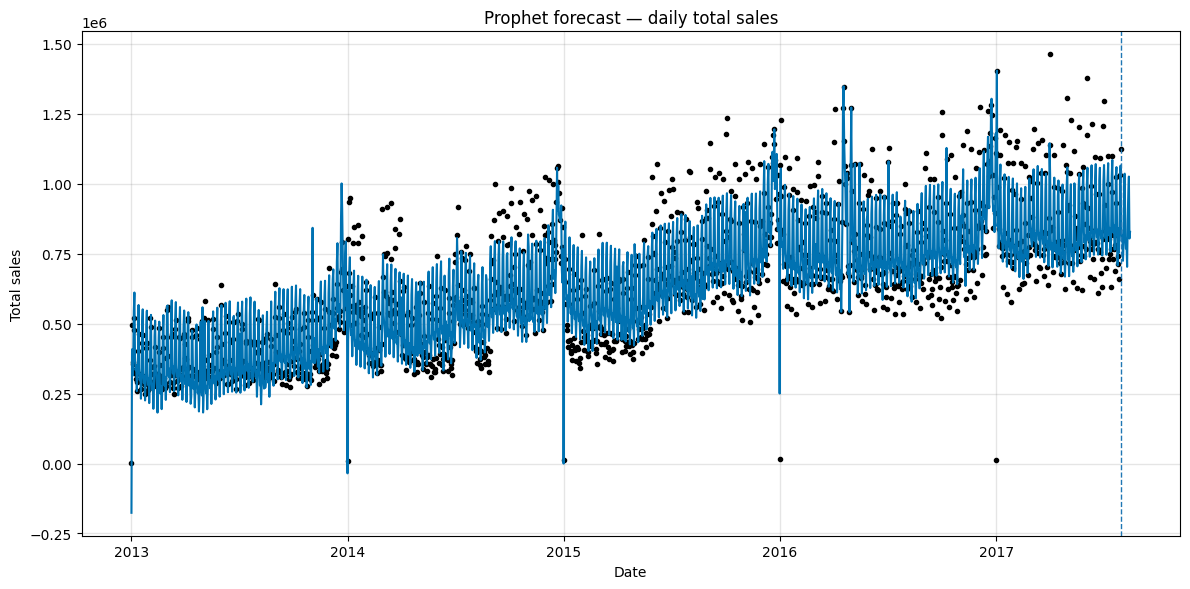

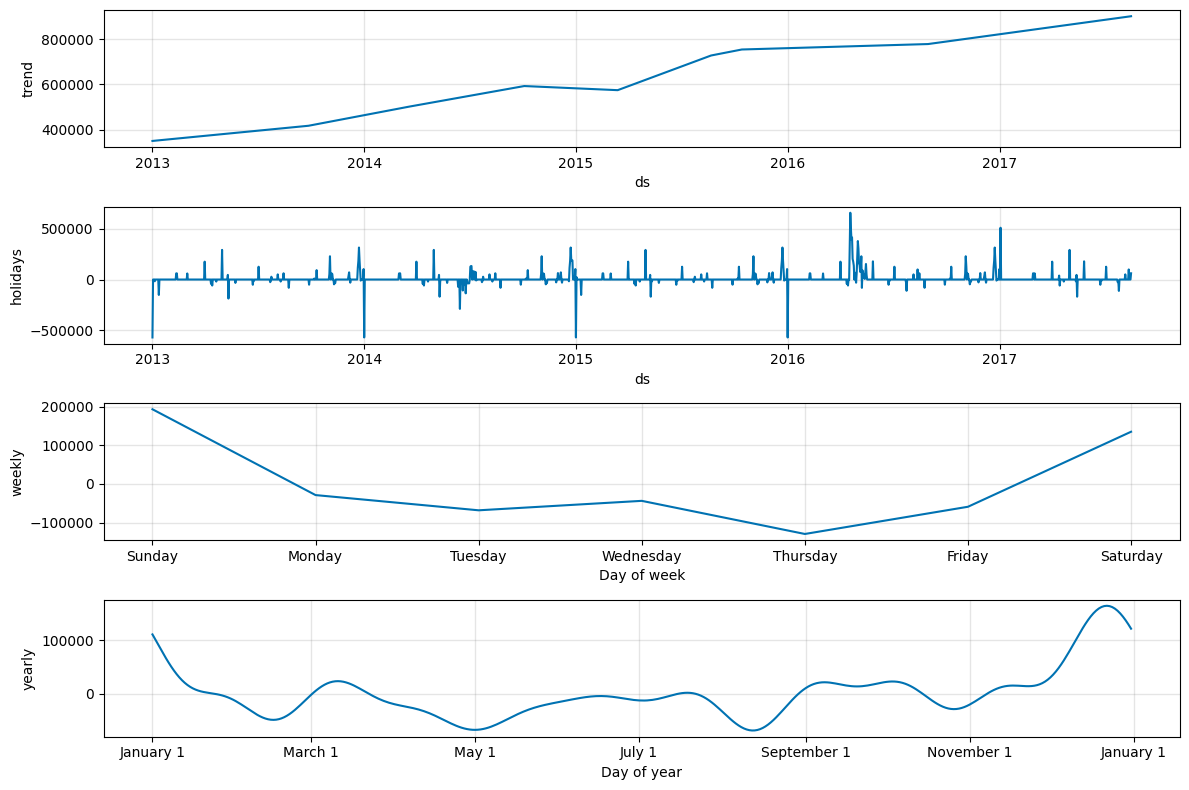

,figure,path,exists,file_size_mb
0,prophet_forecast,reports\figures\prophet_total_sales_v1_forecas...,True,0.2200
1,prophet_components,reports\figures\prophet_total_sales_v1_compone...,True,0.1300


In [6]:
import matplotlib.pyplot as plt

prophet_component_dates = pd.DataFrame(
    {"ds": prophet_full_validation_series["ds"].sort_values().unique()}
)

prophet_component_forecast = prophet_model.predict(prophet_component_dates)

component_columns = [
    column
    for column in [
        "trend",
        "weekly",
        "yearly",
        "holidays",
    ]
    if column in prophet_component_forecast.columns
]

validation_component_forecast = prophet_component_forecast.loc[
    prophet_component_forecast["ds"].between(
        VALIDATION_START_DATE,
        VALIDATION_END_DATE,
    )
].copy()

validation_component_summary = pd.DataFrame(
    [
        {
            "component": component,
            "mean_value": validation_component_forecast[component].mean(),
            "min_value": validation_component_forecast[component].min(),
            "max_value": validation_component_forecast[component].max(),
            "absolute_mean_value": validation_component_forecast[component]
            .abs()
            .mean(),
        }
        for component in component_columns
    ]
).sort_values("absolute_mean_value", ascending=False)

validation_component_detail = validation_component_forecast[
    ["ds", "yhat"] + component_columns
].merge(
    prophet_valid_series[["ds", "y"]],
    on="ds",
    how="left",
)

validation_component_detail["residual"] = (
    validation_component_detail["yhat"] - validation_component_detail["y"]
)

validation_component_detail["absolute_error"] = validation_component_detail[
    "residual"
].abs()

validation_component_detail["day_name"] = validation_component_detail[
    "ds"
].dt.day_name()

weekly_component_summary = (
    validation_component_detail.groupby("day_name", as_index=False)
    .agg(
        days=("ds", "count"),
        mean_weekly_effect=("weekly", "mean"),
        mean_actual_sales=("y", "mean"),
        mean_predicted_sales=("yhat", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
    )
    .sort_values("mean_weekly_effect", ascending=False)
)

if "holidays" in validation_component_detail.columns:
    holiday_component_detail = validation_component_detail.loc[
        validation_component_detail["holidays"].abs() > 0
    ].copy()
else:
    holiday_component_detail = pd.DataFrame()

display(validation_component_summary)
display(validation_component_detail)
display(weekly_component_summary)

if not holiday_component_detail.empty:
    display(holiday_component_detail)

forecast_figure = prophet_model.plot(prophet_component_forecast)
forecast_figure.set_size_inches(12, 6)

forecast_axis = forecast_figure.gca()
forecast_axis.axvline(
    VALIDATION_START_DATE,
    linestyle="--",
    linewidth=1,
)
forecast_axis.set_title("Prophet forecast — daily total sales")
forecast_axis.set_xlabel("Date")
forecast_axis.set_ylabel("Total sales")

forecast_figure.tight_layout()
forecast_figure.savefig(PROPHET_FORECAST_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()

components_figure = prophet_model.plot_components(prophet_component_forecast)
components_figure.set_size_inches(12, 8)
components_figure.tight_layout()
components_figure.savefig(PROPHET_COMPONENTS_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()

figure_inventory = pd.DataFrame(
    [
        {
            "figure": "prophet_forecast",
            "path": PROPHET_FORECAST_FIGURE_PATH.relative_to(PROJECT_ROOT),
            "exists": PROPHET_FORECAST_FIGURE_PATH.exists(),
            "file_size_mb": format_file_size_mb(PROPHET_FORECAST_FIGURE_PATH),
        },
        {
            "figure": "prophet_components",
            "path": PROPHET_COMPONENTS_FIGURE_PATH.relative_to(PROJECT_ROOT),
            "exists": PROPHET_COMPONENTS_FIGURE_PATH.exists(),
            "file_size_mb": format_file_size_mb(PROPHET_COMPONENTS_FIGURE_PATH),
        },
    ]
)

display(figure_inventory)


### Section conclusion

Prophet provides a useful interpretation of aggregate daily sales behavior.

The forecast is mainly driven by a stable trend around 899k daily sales, combined with strong weekly seasonality. Prophet assigns positive weekly effects to weekends, especially Sunday and Saturday, and negative effects to weekdays such as Thursday and Tuesday.

The yearly component is negative during the validation period, reducing the forecast by around 56k sales per day on average. Holiday effects are also present, but their average impact is smaller than the weekly and yearly components.

This decomposition explains why Prophet is useful as an interpretable benchmark: it clearly shows how trend, weekly patterns, yearly seasonality, and holidays contribute to the forecast.

However, the component analysis also helps explain Prophet's weaker validation performance compared with LightGBM. In some validation days, especially weekends, Prophet applies a strong positive weekly effect that leads to overprediction. This confirms that Prophet captures broad aggregate patterns, but it is less precise than LightGBM for this forecasting system.


# 10.Business Interpretation

This section summarizes what Prophet adds to the project from a business and modeling perspective.

Prophet is not selected as the main forecasting model, but it provides a useful interpretable benchmark for aggregate demand behavior.


### Business interpretation

Prophet captures relevant aggregate sales patterns, especially trend and weekly seasonality.

At daily total sales level, Prophet achieves a RMSLE of 0.1070 and a WAPE of 8.80%. This means it can provide a reasonable forecast of total business volume over the validation period.

However, LightGBM remains clearly stronger at the same aggregate level. When LightGBM predictions are aggregated by date, it achieves a RMSLE of 0.0574 and a WAPE of 4.33%. LightGBM also keeps total forecast bias almost neutral, while Prophet overpredicts total validation sales by 2.13%.

From a business perspective, Prophet is useful for understanding high-level demand patterns, such as stronger weekend sales, weekday effects, yearly seasonality, and holiday impacts. This makes it valuable as an explanatory benchmark.

However, Prophet does not use store-level, family-level, promotion-level, or lag-based granular features. Because of this, it cannot capture many operational drivers that are important for replenishment decisions.

The comparison reinforces the modeling decision from notebook 04: LightGBM is the stronger main model for granular forecasting, while Prophet is useful as a complementary aggregate time series benchmark.


### Section conclusion

Prophet adds interpretability, but LightGBM remains the preferred production candidate.

Prophet is useful for explaining aggregate sales behavior through trend, weekly seasonality, yearly effects, and holidays. However, LightGBM provides better validation accuracy and lower aggregate bias, even when evaluated at the same daily total sales level.

The final modeling interpretation is that Prophet is a valuable comparison model, but not the main forecasting model for this project.


# 11.Save Prophet Artifacts

This section saves the Prophet comparison artifacts.

The saved outputs include the trained Prophet model, validation predictions, aggregate metrics, Prophet vs LightGBM comparison tables, component summaries, figures, configuration, and experiment metadata.

These artifacts make the Prophet comparison reproducible and ready for future reporting, MLflow tracking, and README documentation.


In [ ]:
PROPHET_COMPONENT_SUMMARY_PATH = (
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_component_summary.csv"
)

PROPHET_COMPONENT_DETAIL_PATH = (
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_validation_component_detail.csv"
)

PROPHET_WEEKLY_COMPONENT_SUMMARY_PATH = (
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_weekly_component_summary.csv"
)

PROPHET_AGGREGATE_MODEL_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_aggregate_model_comparison.csv"
)

PROPHET_TRAINING_SUMMARY_PATH = (
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_training_summary.csv"
)


def make_json_serializable(value):
    """
    Convert common Python, NumPy, pandas, and pathlib objects into JSON-serializable values.
    """
    if isinstance(value, Path):
        return str(value)

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        return float(value)

    if isinstance(value, (np.ndarray,)):
        return value.tolist()

    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()

    if isinstance(value, dict):
        return {str(key): make_json_serializable(item) for key, item in value.items()}

    if isinstance(value, (list, tuple)):
        return [make_json_serializable(item) for item in value]

    return value


def save_json_str(json_string, path):
    """Save a JSON string to disk."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        file.write(json_string)


def save_json_clean(data, path):
    """Save a dictionary as a formatted JSON file with type normalization."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(
            make_json_serializable(data),
            file,
            indent=4,
            ensure_ascii=False,
        )


save_json_str(
    model_to_json(prophet_model),
    PROPHET_MODEL_PATH,
)

save_dataframe_parquet(
    prophet_validation_predictions,
    PROPHET_VALIDATION_PREDICTIONS_PATH,
)

save_dataframe_csv(prophet_metrics, PROPHET_METRICS_PATH)
save_dataframe_csv(daily_comparison, PROPHET_DAILY_COMPARISON_PATH)
save_dataframe_csv(aggregate_model_comparison, PROPHET_AGGREGATE_MODEL_COMPARISON_PATH)
save_dataframe_csv(
    prophet_vs_lightgbm_summary,
    REPORTS_TABLES_DIR / f"{MODEL_VERSION}_vs_lightgbm_summary.csv",
)
save_dataframe_csv(prophet_training_summary, PROPHET_TRAINING_SUMMARY_PATH)

save_dataframe_csv(validation_component_summary, PROPHET_COMPONENT_SUMMARY_PATH)
save_dataframe_csv(validation_component_detail, PROPHET_COMPONENT_DETAIL_PATH)
save_dataframe_csv(weekly_component_summary, PROPHET_WEEKLY_COMPONENT_SUMMARY_PATH)

prophet_config = {
    "model_version": MODEL_VERSION,
    "created_at": datetime.now(),
    "model_type": "Prophet aggregate daily time series",
    "scope": "daily_total_sales",
    "target": "total_daily_sales",
    "training_period": {
        "start_date": prophet_training_data["ds"].min(),
        "end_date": prophet_training_data["ds"].max(),
        "rows": len(prophet_training_data),
    },
    "validation_period": {
        "start_date": prophet_validation_predictions["ds"].min(),
        "end_date": prophet_validation_predictions["ds"].max(),
        "rows": len(prophet_validation_predictions),
    },
    "prophet_params": prophet_params,
    "holidays": {
        "used": prophet_holidays is not None,
        "rows": len(prophet_holidays) if prophet_holidays is not None else 0,
        "unique_dates": (
            prophet_holidays["ds"].nunique() if prophet_holidays is not None else 0
        ),
        "unique_holidays": (
            prophet_holidays["holiday"].nunique() if prophet_holidays is not None else 0
        ),
    },
    "main_validation_metrics": prophet_metrics.iloc[0].to_dict(),
    "lightgbm_aggregate_comparison": prophet_vs_lightgbm_summary.iloc[0].to_dict(),
    "artifact_paths": {
        "model": PROPHET_MODEL_PATH,
        "validation_predictions": PROPHET_VALIDATION_PREDICTIONS_PATH,
        "metrics": PROPHET_METRICS_PATH,
        "daily_comparison": PROPHET_DAILY_COMPARISON_PATH,
        "aggregate_model_comparison": PROPHET_AGGREGATE_MODEL_COMPARISON_PATH,
        "component_summary": PROPHET_COMPONENT_SUMMARY_PATH,
        "component_detail": PROPHET_COMPONENT_DETAIL_PATH,
        "weekly_component_summary": PROPHET_WEEKLY_COMPONENT_SUMMARY_PATH,
        "forecast_figure": PROPHET_FORECAST_FIGURE_PATH,
        "components_figure": PROPHET_COMPONENTS_FIGURE_PATH,
    },
}

save_json_clean(prophet_config, PROPHET_CONFIG_PATH)

prophet_experiment_summary = {
    "model_version": MODEL_VERSION,
    "decision": "kept_as_interpretable_aggregate_benchmark",
    "main_model_comparison": "lightgbm_v1_daily_aggregate",
    "main_results": {
        "prophet_rmsle": prophet_metrics["rmsle"].iloc[0],
        "prophet_mae": prophet_metrics["mae"].iloc[0],
        "prophet_wape": prophet_metrics["wape"].iloc[0],
        "prophet_total_bias_pct": prophet_metrics["total_bias_pct"].iloc[0],
        "lightgbm_daily_rmsle": lightgbm_daily_metrics["rmsle"].iloc[0],
        "lightgbm_daily_mae": lightgbm_daily_metrics["mae"].iloc[0],
        "lightgbm_daily_wape": lightgbm_daily_metrics["wape"].iloc[0],
        "lightgbm_daily_total_bias_pct": lightgbm_daily_metrics["total_bias_pct"].iloc[
            0
        ],
    },
    "interpretation": {
        "main_strengths": [
            "Provides interpretable aggregate time series decomposition.",
            "Captures trend, weekly seasonality, yearly seasonality, and holiday effects.",
            "Runs quickly and is lightweight at daily aggregate level.",
            "Useful as a benchmark for total business volume.",
        ],
        "main_limitations": [
            "Does not use store-level or family-level information.",
            "Does not use promotion-level features.",
            "Does not use lag or rolling features at granular level.",
            "Underperforms LightGBM at daily aggregate validation level.",
            "Shows positive aggregate bias during the validation period.",
        ],
        "business_decision": (
            "Prophet is useful as an interpretable aggregate benchmark, "
            "but LightGBM remains the preferred main forecasting model."
        ),
    },
    "mlflow_ready_metadata": {
        "params": prophet_params,
        "metrics": prophet_metrics.iloc[0].to_dict(),
        "tags": {
            "model_version": MODEL_VERSION,
            "model_family": "prophet",
            "forecast_level": "daily_total_sales",
            "comparison_model": "lightgbm_v1_daily_aggregate",
            "validation_strategy": "temporal_holdout_16_days",
        },
        "artifacts": [
            str(PROPHET_MODEL_PATH),
            str(PROPHET_CONFIG_PATH),
            str(PROPHET_VALIDATION_PREDICTIONS_PATH),
            str(PROPHET_METRICS_PATH),
            str(PROPHET_DAILY_COMPARISON_PATH),
            str(PROPHET_AGGREGATE_MODEL_COMPARISON_PATH),
            str(PROPHET_COMPONENT_SUMMARY_PATH),
            str(PROPHET_FORECAST_FIGURE_PATH),
            str(PROPHET_COMPONENTS_FIGURE_PATH),
        ],
    },
}

save_json_clean(prophet_experiment_summary, PROPHET_EXPERIMENT_SUMMARY_PATH)

saved_prophet_artifacts = {
    "model": PROPHET_MODEL_PATH,
    "config": PROPHET_CONFIG_PATH,
    "experiment_summary": PROPHET_EXPERIMENT_SUMMARY_PATH,
    "validation_predictions": PROPHET_VALIDATION_PREDICTIONS_PATH,
    "metrics": PROPHET_METRICS_PATH,
    "daily_comparison": PROPHET_DAILY_COMPARISON_PATH,
    "aggregate_model_comparison": PROPHET_AGGREGATE_MODEL_COMPARISON_PATH,
    "training_summary": PROPHET_TRAINING_SUMMARY_PATH,
    "component_summary": PROPHET_COMPONENT_SUMMARY_PATH,
    "component_detail": PROPHET_COMPONENT_DETAIL_PATH,
    "weekly_component_summary": PROPHET_WEEKLY_COMPONENT_SUMMARY_PATH,
    "forecast_figure": PROPHET_FORECAST_FIGURE_PATH,
    "components_figure": PROPHET_COMPONENTS_FIGURE_PATH,
}

saved_prophet_artifacts_inventory = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "path": artifact_path,
            "relative_path": artifact_path.relative_to(PROJECT_ROOT),
            "exists": artifact_path.exists(),
            "file_size_mb": format_file_size_mb(artifact_path),
        }
        for artifact_name, artifact_path in saved_prophet_artifacts.items()
    ]
)

display(saved_prophet_artifacts_inventory)

missing_prophet_artifacts = saved_prophet_artifacts_inventory.loc[
    ~saved_prophet_artifacts_inventory["exists"]
]

if not missing_prophet_artifacts.empty:
    raise FileNotFoundError(
        "Some Prophet artifacts were not saved correctly:\n"
        + "\n".join(
            [
                f"- {row.artifact}: {row.path}"
                for row in missing_prophet_artifacts.itertuples(index=False)
            ]
        )
    )

print(f"Saved {len(saved_prophet_artifacts_inventory)} Prophet artifacts.")
print(f"Main Prophet model artifact: {PROPHET_MODEL_PATH.relative_to(PROJECT_ROOT)}")


,artifact,path,relative_path,exists,file_size_mb
0,model,....,models\prophet\prophet_total_sales_v1_model.json,True,0.9200
1,config,....,models\prophet\prophet_total_sales_v1_config.json,True,0.0000
2,experiment_summary,....,models\prophet\prophet_total_sales_v1_experime...,True,0.0000
3,validation_predictions,....,data\predictions\prophet_total_sales_v1_valida...,True,0.0100
4,metrics,....,reports\tables\prophet_total_sales_v1_metrics.csv,True,0.0000
5,daily_comparison,....,reports\tables\prophet_total_sales_v1_vs_light...,True,0.0000
6,aggregate_model_comparison,....,reports\tables\prophet_total_sales_v1_aggregat...,True,0.0000
7,training_summary,....,reports\tables\prophet_total_sales_v1_training...,True,0.0000
8,component_summary,....,reports\tables\prophet_total_sales_v1_componen...,True,0.0000
9,component_detail,....,reports\tables\prophet_total_sales_v1_validati...,True,0.0000


Saved 13 Prophet artifacts.
Main Prophet model artifact: models\prophet\prophet_total_sales_v1_model.json


### Section conclusion

The Prophet comparison artifacts have been saved successfully.

The saved outputs include the trained Prophet model, validation predictions, metrics, aggregate comparison against LightGBM, component summaries, figures, configuration, and experiment metadata.

These artifacts make the Prophet experiment reproducible and ready for model comparison, reporting, README documentation, and future MLflow tracking.


# 12.Final Notebook Conclusion

Prophet was evaluated as an interpretable aggregate forecasting benchmark for the Corporación Favorita Store Sales Forecasting project.

The model was trained on daily total sales from 2013-01-01 to 2017-07-30 and validated on the same 16-day holdout period used in the LightGBM notebook, from 2017-07-31 to 2017-08-15.

Prophet achieved the following aggregate validation performance:

* RMSLE: 0.1070;
* MAE: 73,232.56;
* WAPE: 8.80%;
* total forecast bias: +2.13%.

When compared against LightGBM aggregated at daily level, Prophet performed worse:

* LightGBM daily aggregate RMSLE: 0.0574;
* LightGBM daily aggregate WAPE: 4.33%;
* LightGBM total forecast bias: -0.08%.

This confirms that LightGBM remains the stronger forecasting model, even when evaluated at the same aggregate daily sales level.

However, Prophet adds value as an interpretable benchmark. Its component analysis shows that the aggregate forecast is mainly driven by a stable trend around 899k daily sales, strong weekly seasonality, yearly effects, and holiday adjustments. Prophet identifies higher expected sales on weekends, especially Sundays and Saturdays, and lower expected sales on weekdays such as Thursdays and Tuesdays.

The main limitation is that Prophet operates only on the aggregate daily series in this notebook. It does not use store-level, family-level, promotion-level, or lag-based granular features. Because of that, it cannot capture several important operational drivers required for store-family replenishment forecasting.

The final modeling decision is:

* LightGBM remains the main model candidate for granular sales forecasting.
* Prophet is kept as a complementary aggregate benchmark.
* Prophet is useful for explaining global demand patterns, but not for replacing the LightGBM forecasting system.


### Notebook closure

This notebook completed the Prophet comparison workflow:

* required data and LightGBM artifacts were validated;
* daily total sales were aggregated for Prophet;
* Prophet was trained on the historical aggregate sales series;
* the model forecasted the same 16-day validation horizon;
* Prophet metrics were calculated;
* LightGBM predictions were aggregated by date for a fair aggregate comparison;
* Prophet components were analyzed;
* business interpretation was documented;
* model artifacts, metrics, comparison tables, figures, and metadata were saved.

The notebook confirms that Prophet is useful as an interpretable aggregate time series benchmark, while LightGBM remains the preferred model for the forecasting system.
